# 模块五：进阶与霸榜模型 (集成学习)
**案例背景**：大宗商品（铁矿石）库存预测。本 Notebook 涵盖随机森林、XGBoost、LightGBM 等集成模型实战。

---

## 随机森林



来源: 面经知识库 02-tree-models.md §2.4 随机 forest（自建与决策树示例相同的数据）


In [6]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


def make_finance_dataset():
    np.random.seed(42)
    n_samples = 150
    age = np.random.uniform(20, 70, n_samples)
    income = np.random.uniform(3, 50, n_samples)
    y = np.zeros(n_samples)
    for i in range(n_samples):
        if (age[i] > 40 and income[i] > 15) or (age[i] <= 40 and income[i] > 30):
            y[i] = 1
    flip_indices = np.random.choice(n_samples, int(0.1 * n_samples), replace=False)
    y[flip_indices] = 1 - y[flip_indices]
    X = np.column_stack((age, income))
    return train_test_split(X, y, test_size=0.3, random_state=42)


X_train, X_test, y_train, y_test = make_finance_dataset()



## 1. 模型训练


In [7]:
# n_estimators=100 表示使用 100 棵树
rf_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_model.fit(X_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

## 2. 模型预测与评估


In [8]:
rf_pred = rf_model.predict(X_test)
print(f"随机森林准确率: {accuracy_score(y_test, rf_pred):.2f}")



随机森林准确率: 0.84


## 3. 特征重要性


In [9]:
importances = rf_model.feature_importances_
print(f"特征重要性 - 年龄: {importances[0]:.2f}, 收入: {importances[1]:.2f}")


特征重要性 - 年龄: 0.27, 收入: 0.73


---

## XGBoost 分类



来源: 面经知识库 02-tree-models.md §3.4 XGBoost（补全 matplotlib 导入）


In [10]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


def make_finance_dataset():
    np.random.seed(42)
    n_samples = 150
    age = np.random.uniform(20, 70, n_samples)
    income = np.random.uniform(3, 50, n_samples)
    y = np.zeros(n_samples)
    for i in range(n_samples):
        if (age[i] > 40 and income[i] > 15) or (age[i] <= 40 and income[i] > 30):
            y[i] = 1
    flip_indices = np.random.choice(n_samples, int(0.1 * n_samples), replace=False)
    y[flip_indices] = 1 - y[flip_indices]
    X = np.column_stack((age, income))
    return train_test_split(X, y, test_size=0.3, random_state=42)


X_train, X_test, y_train, y_test = make_finance_dataset()



## 1. 转换为 XGBoost 的 DMatrix 格式 (可选，但推荐)


In [11]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)



## 2. 设置参数


In [12]:
params = {
    "max_depth": 3,  # 树的最大深度
    "eta": 0.1,  # 学习率 (learning rate)
    "objective": "binary:logistic",  # 二分类逻辑回归
    "eval_metric": "logloss",  # 评估指标
}
num_round = 50  # 迭代次数（树的个数）



## 3. 模型训练


In [13]:
xgb_model = xgb.train(params, dtrain, num_round)



## 4. 模型预测


In [14]:
# 注意：XGBoost 输出的是概率值，需要手动设置阈值转换为类别
xgb_prob = xgb_model.predict(dtest)
xgb_pred = (xgb_prob > 0.5).astype(int)

print(f"XGBoost 准确率: {accuracy_score(y_test, xgb_pred):.2f}")



XGBoost 准确率: 0.87


## 5. 可视化特征重要性


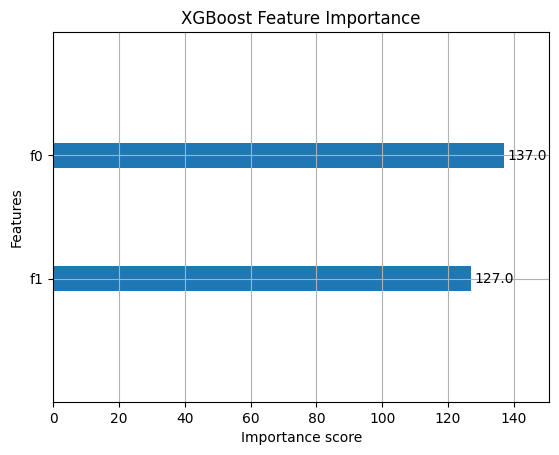

In [15]:
xgb.plot_importance(xgb_model)
plt.title("XGBoost Feature Importance")
if "agg" in mpl.get_backend().lower():
    plt.close("all")
else:
    plt.show()


---

## LightGBM 二分类



来源: 面经知识库 02-tree-models.md §4.4 LightGBM 二分类


In [16]:
import numpy as np
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


def make_finance_dataset():
    np.random.seed(42)
    n_samples = 150
    age = np.random.uniform(20, 70, n_samples)
    income = np.random.uniform(3, 50, n_samples)
    y = np.zeros(n_samples)
    for i in range(n_samples):
        if (age[i] > 40 and income[i] > 15) or (age[i] <= 40 and income[i] > 30):
            y[i] = 1
    flip_indices = np.random.choice(n_samples, int(0.1 * n_samples), replace=False)
    y[flip_indices] = 1 - y[flip_indices]
    X = np.column_stack((age, income))
    return train_test_split(X, y, test_size=0.3, random_state=42)


X_train, X_test, y_train, y_test = make_finance_dataset()



## 1. 转换为 LightGBM 的 Dataset 格式


In [17]:
lgb_train = lgb.Dataset(X_train, y_train)
lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train)



## 2. 设置参数


In [18]:
params = {
    "boosting_type": "gbdt",
    "objective": "binary",
    "metric": "binary_logloss",
    "num_leaves": 31,  # Leaf-wise 核心参数，控制树的复杂度
    "learning_rate": 0.05,
    "feature_fraction": 0.9,
    "verbose": -1,  # 关闭打印信息
}



## 3. 模型训练


In [19]:
gbm = lgb.train(params, lgb_train, num_boost_round=100, valid_sets=[lgb_train, lgb_eval])



## 4. 模型预测


In [20]:
# LightGBM 输出的也是概率值
lgb_prob = gbm.predict(X_test, num_iteration=gbm.best_iteration)
lgb_pred = (lgb_prob > 0.5).astype(int)

print(f"LightGBM 准确率: {accuracy_score(y_test, lgb_pred):.2f}")


LightGBM 准确率: 0.87


---

## 铁矿石库存预测 LightGBM



来源: 面经知识库 02-tree-models.md §5.3 铁矿石库存预测 LightGBM


In [21]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings("ignore")



## 1. 模拟生成铁矿石周度数据 (约3年, 156周)


In [22]:
np.random.seed(42)
n_weeks = 156
dates = pd.date_range(start="2021-01-01", periods=n_weeks, freq="W")

# 模拟基础数据：带有年内复合周期和噪声
t = np.arange(n_weeks)
# 进货量：基础量 + 年周期 + 半年周期 + 噪声
inbound = 500 + 50 * np.sin(2 * np.pi * t / 52) + 20 * np.cos(2 * np.pi * t / 26) + np.random.normal(0, 20, n_weeks)
# 出货量：基础量 + 年周期 + 噪声 (存在一定的时间差)
outbound = 490 + 60 * np.sin(2 * np.pi * t / 52 - 0.5) + np.random.normal(0, 25, n_weeks)
# 日度价格指数聚合为周度：随机游走带漂移
price_index = 100 + np.cumsum(np.random.normal(0.1, 1.5, n_weeks))

# 模拟库存 (库存 = 上期库存 + 进货 - 出货 + 损耗/噪声)
inventory = np.zeros(n_weeks)
inventory[0] = 5000
for i in range(1, n_weeks):
    inventory[i] = inventory[i - 1] + inbound[i] - outbound[i] + np.random.normal(0, 5)

df = pd.DataFrame({"date": dates, "inventory": inventory, "inbound": inbound, "outbound": outbound, "price_index": price_index})
df.set_index("date", inplace=True)



## 2. 特征工程 (Feature Engineering)


In [23]:
# 目标变量：预测下一周的库存变化量 (一阶差分，因为树模型难以外推库存绝对值的趋势)
df["target_inv_change"] = df["inventory"].shift(-1) - df["inventory"]

# 2.1 业务交叉特征
df["net_inbound"] = df["inbound"] - df["outbound"]  # 净进货量
df["depletion_cycle"] = df["inventory"] / (df["outbound"].rolling(window=4, min_periods=1).mean() + 1e-5)  # 去化周期

# 2.2 价格动量 (对数收益率，处理价格的非平稳性)
df["price_return_1w"] = np.log(df["price_index"] / df["price_index"].shift(1))
df["price_return_4w"] = np.log(df["price_index"] / df["price_index"].shift(4))

# 价格动量与进货量的交叉 (买涨不买跌情绪)
df["momentum_x_inbound"] = df["price_return_1w"] * df["inbound"]

# 2.3 滞后与滚动特征 (严格使用 shift 避免未来函数泄露)
for col in ["inventory", "inbound", "outbound", "net_inbound"]:
    # 滞后 1周(近期), 4周(月度), 12周(季度)
    for lag in [1, 4, 12]:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)
    # 滚动均值与波动率 (注意必须先 shift(1) 再 rolling，否则会泄露当周信息给当周特征)
    df[f"{col}_roll_mean4"] = df[col].shift(1).rolling(window=4).mean()
    df[f"{col}_roll_std4"] = df[col].shift(1).rolling(window=4).std()

# 2.4 周期性与节假日特征
df["month"] = df.index.month
df["weekofyear"] = df.index.isocalendar().week.astype(int)

# 模拟距离春节的周数 (假设每年第6周左右是春节)
df["weeks_to_spring_fest"] = (6 - df["weekofyear"]) % 52
df["weeks_to_spring_fest"] = df["weeks_to_spring_fest"].apply(lambda x: x if x <= 26 else 52 - x)

# 剔除因构造滞后和目标变量产生的 NaN
df.dropna(inplace=True)



## 3. 时间序列切分 (Time Series Split)


In [24]:
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

features = [c for c in df.columns if c not in ["target_inv_change"]]
X_train, y_train = train_df[features], train_df["target_inv_change"]
X_test, y_test = test_df[features], test_df["target_inv_change"]



## 4. LightGBM 模型训练


In [25]:
categorical_features = ["month", "weekofyear"]

lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=categorical_features)
lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train, categorical_feature=categorical_features)

params = {
    "boosting_type": "gbdt",
    "objective": "regression",  # 回归任务
    "metric": "mae",
    "num_leaves": 15,
    "learning_rate": 0.05,
    "feature_fraction": 0.8,
    "verbose": -1,
    "random_state": 42,
}

gbm = lgb.train(params, lgb_train, num_boost_round=300, valid_sets=[lgb_train, lgb_eval], callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)])



## 5. 模型预测与评估


In [26]:
y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration)
print(f"测试集 MAE (库存变化量): {mean_absolute_error(y_test, y_pred):.2f} 吨")
print(f"测试集 RMSE (库存变化量): {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} 吨")

predicted_inventory = test_df["inventory"] + y_pred
print(
    "测试集绝对库存预测 MAPE: "
    f"{np.mean(np.abs((test_df['inventory'].shift(-1) - predicted_inventory) / test_df['inventory'].shift(-1))):.4%}"
)



测试集 MAE (库存变化量): 26.30 吨
测试集 RMSE (库存变化量): 31.32 吨
测试集绝对库存预测 MAPE: 0.4615%


## 6. 特征重要性可视化


<Figure size 1000x600 with 0 Axes>

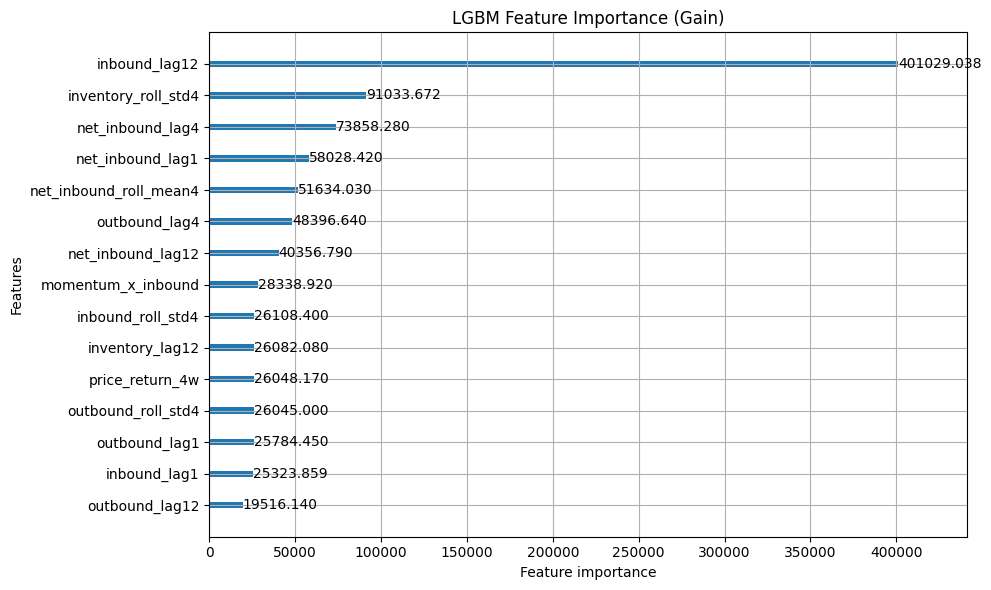

In [27]:
plt.figure(figsize=(10, 6))
lgb.plot_importance(gbm, max_num_features=15, importance_type="gain", title="LGBM Feature Importance (Gain)", figsize=(10, 6))
plt.tight_layout()
if "agg" in mpl.get_backend().lower():
    plt.close("all")
else:
    plt.show()
